# Letters

## Description

Generate an image with the edges of the letters present in this noisy image


## Group ID

Identify your group here, including the number and name of each group's member

In [1]:
import cv2
# to install cv2 use: pip install opencv-python
import matplotlib.pyplot as plt 
import numpy as np

In [2]:
def notch_reject_filter_gaussian(shape: tuple[int, int], d0: int, u_k: int, v_k: int):
    (W, H) = shape
    H_0_u, H_0_v = np.meshgrid(np.arange(H), np.arange(W)) # Mais eficiente que np.repeat
    
    # Distância aos pontos de ruído (u_k, v_k) e ao seu simétrico
    D_uv = np.sqrt((H_0_u - H / 2 + v_k) ** 2 + (H_0_v - W / 2 + u_k) ** 2)
    D_muv = np.sqrt((H_0_u - H / 2 - v_k) ** 2 + (H_0_v - W / 2 - u_k) ** 2)
    
    # Filtro Gaussiano: 1 - exp(-D^2 / 2*d0^2)
    mask = (1 - np.exp(-(D_uv**2) / (2 * (d0**2)))) * (1 - np.exp(-(D_muv**2) / (2 * (d0**2))))
    
    # Converter para o formato (W, H, 2) que o cv2.dft espera
    H_mask = np.zeros((W, H, 2))
    H_mask[:, :, 0] = mask
    H_mask[:, :, 1] = mask
    return H_mask

(400, 600)


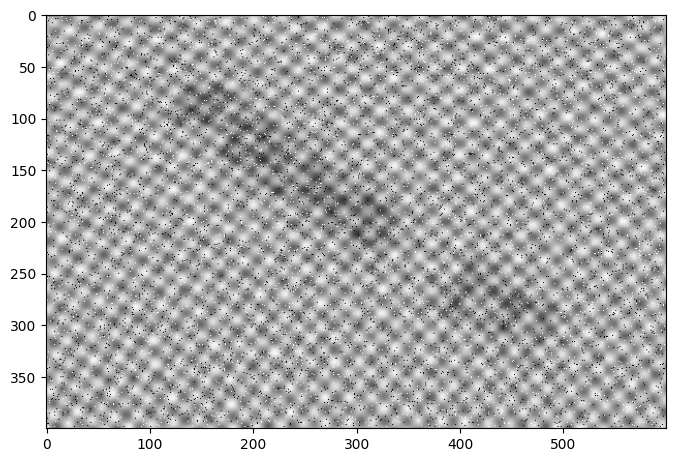

In [ ]:
fname = '../Letters-noisy.png'
img = cv2.imread(fname,cv2.IMREAD_GRAYSCALE)
W,H=img.shape
print(img.shape)
ratio=H/W
fig = plt.figure(figsize=(8,8*ratio))
plt.imshow(img, cmap='gray')

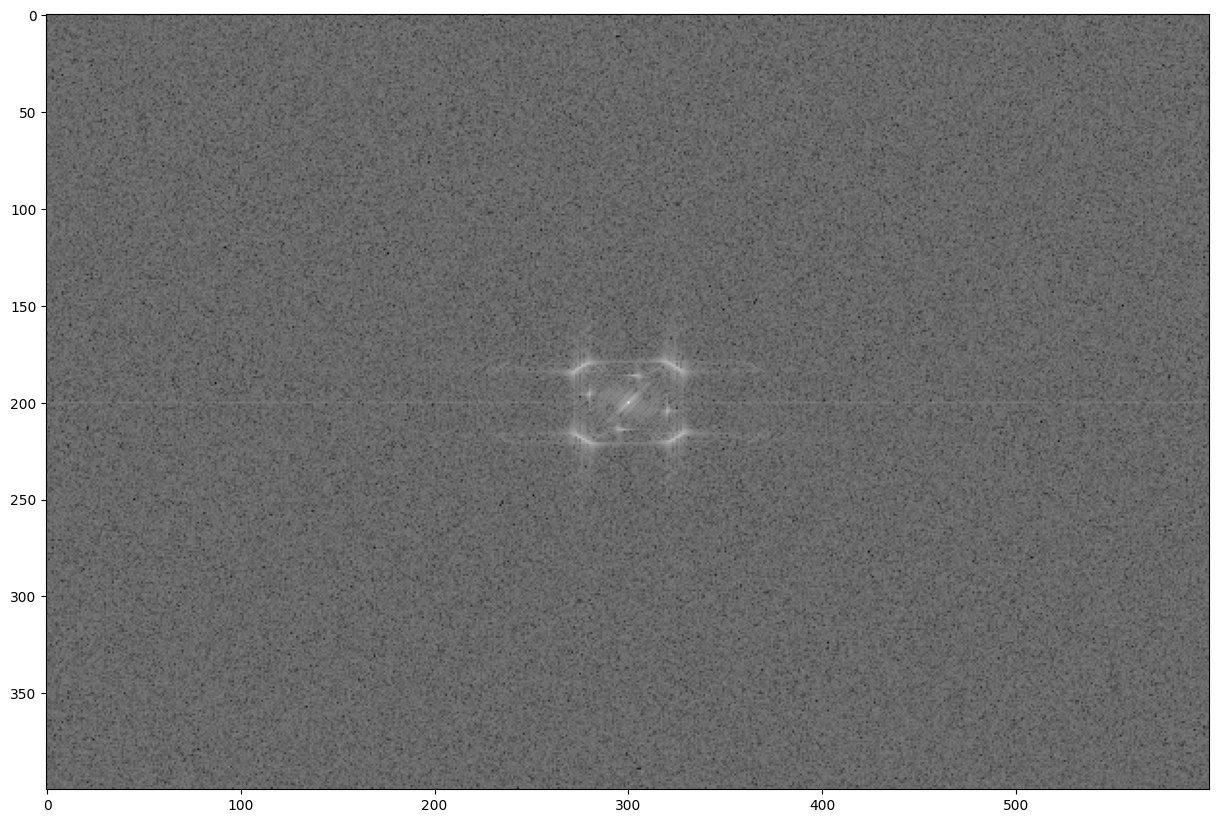

In [4]:
# convert the image representation to SPFP
img_float32 = np.float32(img)

dft = cv2.dft(img_float32, flags = cv2.DFT_COMPLEX_OUTPUT)

# recenter the DFT , such that the center is (0,0)
dft_shift = np.fft.fftshift(dft)
# compute the frequency spectrum
# module of the complex value
magnitude_spectrum = cv2.magnitude(dft_shift[:,:,0],dft_shift[:,:,1])
# compute the logarith of magnitude such that smaller values are visible
magnitude_spectrum = 20*np.log(magnitude_spectrum)

fig = plt.figure(figsize=(15,8*ratio))
plt.imshow(magnitude_spectrum, cmap='gray')

In [5]:
# 1. Deteção automática de picos de ruído no espectro de frequência

# Limiarizar o espectro de magnitude para encontrar picos de ruído
# Usamos um limiar alto para isolar apenas os pontos mais brilhantes (ruído)
# Usando 98% do valor máximo como limiar
thresh_val = 0.98 * magnitude_spectrum.max()
ret, thresh = cv2.threshold(magnitude_spectrum, thresh_val, 255, cv2.THRESH_BINARY)
thresh = thresh.astype(np.uint8)

# Encontrar contornos dos picos de ruído
# Estamos interessados apenas nos contornos externos
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Centro do espectro
(W, H) = img.shape
center_x, center_y = H // 2, W // 2

# Distância mínima do centro para não filtrar o sinal principal
min_dist_from_center = 30 

# Raio para os filtros notch
notch_radius = 15

# Inicializar a máscara de filtro combinada como uma matriz de uns
H = np.ones((W, H, 2))

# 2. Criar e combinar filtros notch para cada pico detetado

for c in contours:
    # Calcular o centro do contorno
    M = cv2.moments(c)
    if M["m00"] == 0:
        continue
    cX = int(M["m10"] / M["m00"])
    cY = int(M["m01"] / M["m00"])
    
    # Calcular a distância do centro do espectro
    dist = np.sqrt((cX - center_x)**2 + (cY - center_y)**2)
    
    # Se o pico estiver longe o suficiente do centro, criar um filtro notch para ele
    if dist > min_dist_from_center:
        # As coordenadas para o filtro notch são relativas ao centro
        u_k = cX - center_x
        v_k = cY - center_y
        
        # Criar um filtro notch para o pico atual
        H_notch = notch_reject_filter_gaussian(img.shape, notch_radius, u_k, v_k)
        
        # Combiná-lo com o filtro principal
        H *= H_notch

# 3. Aplicar o filtro combinado

# Aplicar a máscara à DFT
dft_masked = dft_shift * H

# Desfazer a centralização
dft_masked_ishift = np.fft.ifftshift(dft_masked)

# Calcular a DFT inversa
img_back = cv2.idft(dft_masked_ishift)

# O resultado deve ser uma imagem real, então pegamos a magnitude
img_back = cv2.magnitude(img_back[:,:,0], img_back[:,:,1])

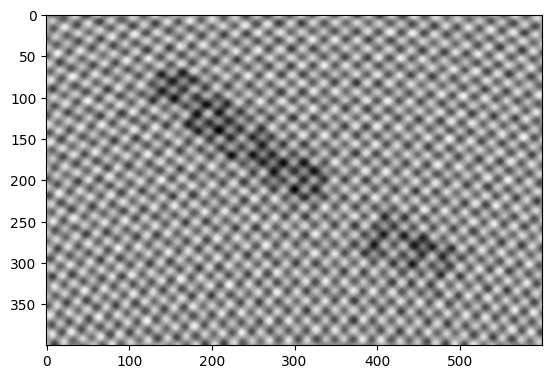

In [6]:
# 1. Normalizar
img_res = cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# 2. Remover ruído residual ("sal e pimenta")
img_clean = cv2.medianBlur(img_res, 5)

# 3. Binarização Automática (Otsu) - Isto dará a nitidez final
_, thresh = cv2.threshold(img_clean, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Mostrar resultado
plt.imshow(img_clean, cmap='gray')

In [7]:
# compute the DFT of the processed image (img_back)
# Note that the computed DFT has 2 channels :
# dft[:,:,0] - real values
# dft[:,:,1] - imaginary values
dft_proc = cv2.dft(img_back, flags = cv2.DFT_COMPLEX_OUTPUT)
# recenter the DFT , such that the center is (0,0)
dft_proc_shift = np.fft.fftshift(dft_proc)
# compute the frequency spectrum
# module of the complex value
filtered_spectrum = cv2.magnitude(dft_proc_shift[:,:,0],dft_proc_shift[:,:,1])
# compute the logarith of magnitude such that smaller values are visible
filtered_spectrum = 20*np.log(filtered_spectrum)

In [8]:
# compute the frequency spectrum of the MASK, 
# just for display purposes
# module of the complex value
mask_spectrum = np.sqrt(np.power(H[:,:,0],2)+np.power(H[:,:,1],2))
# compute the logarith of magnitude such that smaller values are visible
mask_spectrum = 20*np.log(mask_spectrum+0.0001)

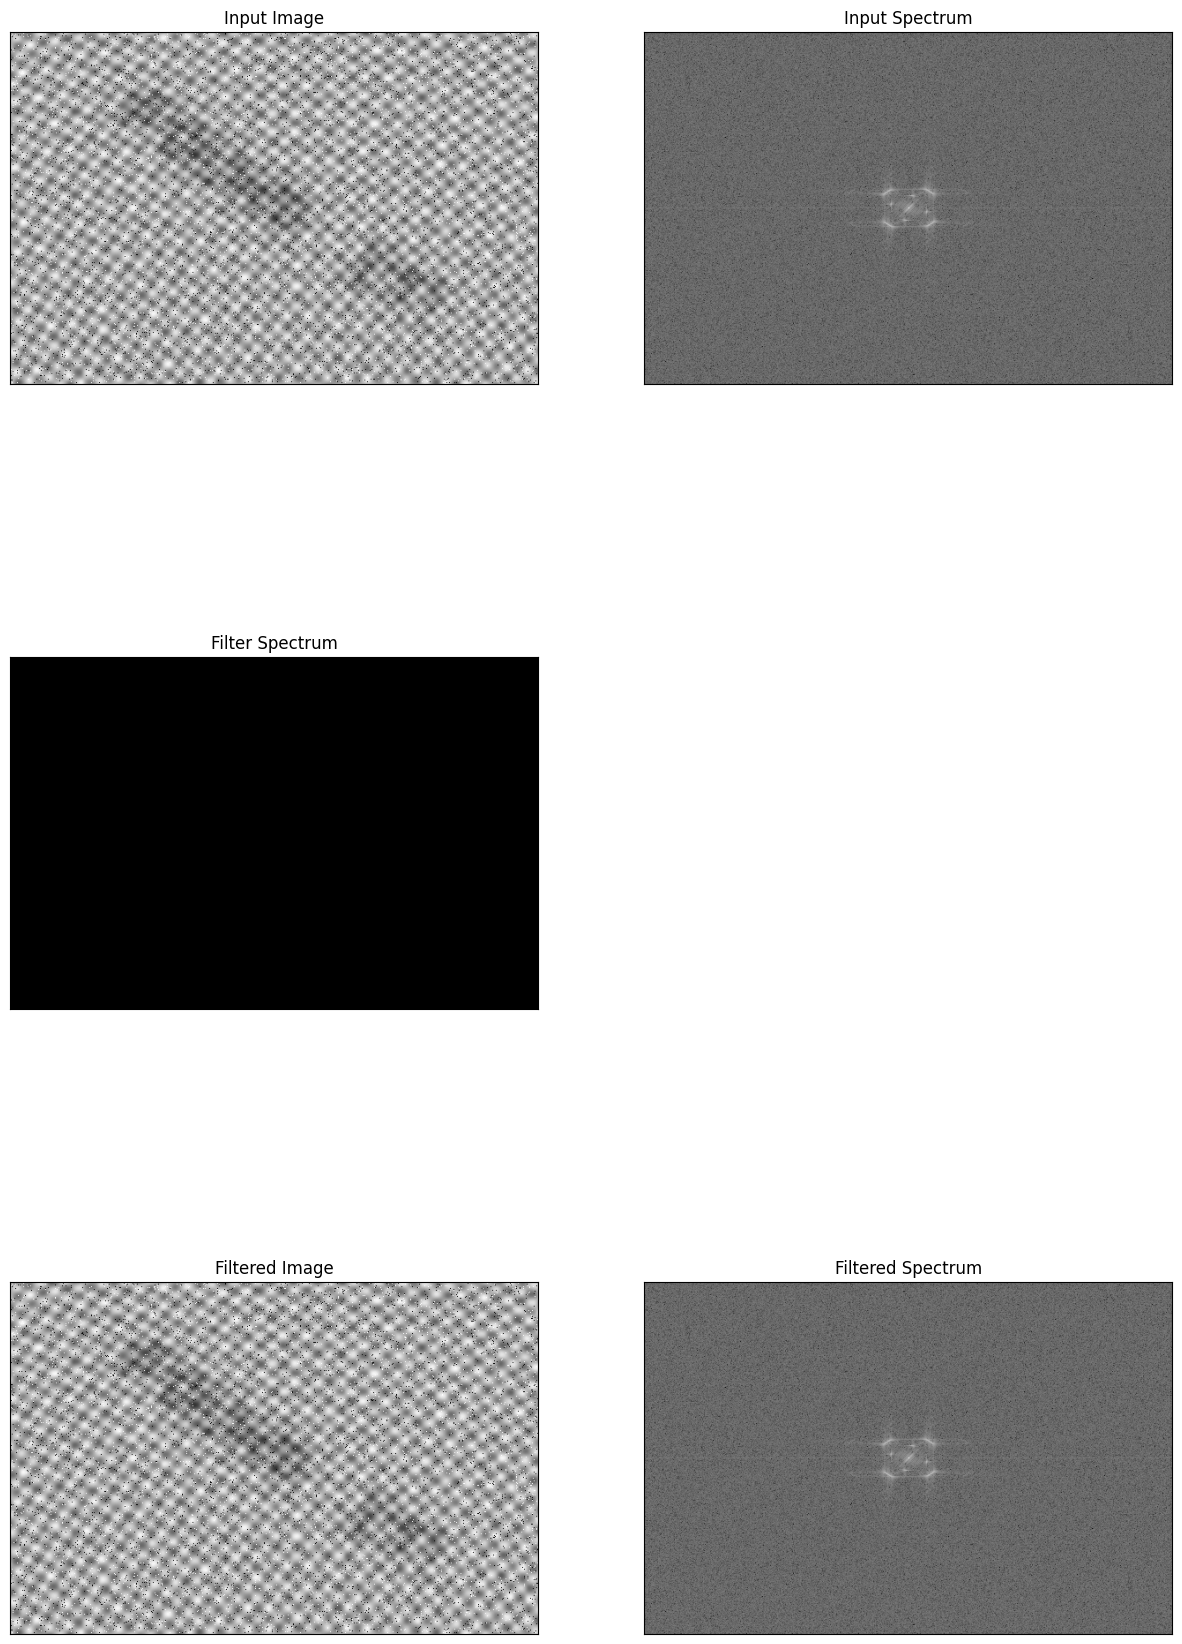

In [9]:
# display the image and the spectrum
fig = plt.figure(figsize=(15,23))
plt.subplot(321),plt.imshow(img, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(322),plt.imshow(magnitude_spectrum, cmap = 'gray')
plt.title('Input Spectrum'), plt.xticks([]), plt.yticks([])
plt.subplot(323),plt.imshow(mask_spectrum, cmap = 'gray')
plt.title('Filter Spectrum'), plt.xticks([]), plt.yticks([])
plt.subplot(325),plt.imshow(img_back, cmap = 'gray')
plt.title('Filtered Image'), plt.xticks([]), plt.yticks([])
plt.subplot(326),plt.imshow(filtered_spectrum, cmap = 'gray')
plt.title('Filtered Spectrum'), plt.xticks([]), plt.yticks([])
plt.show()         

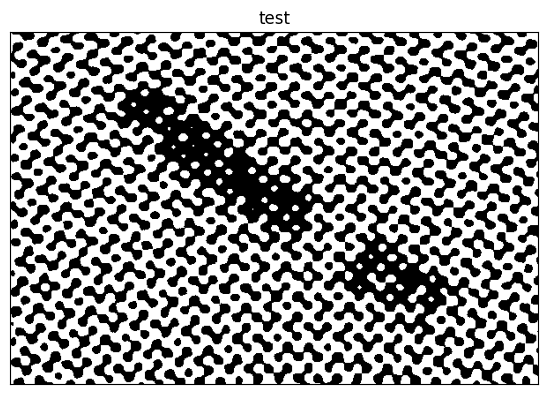

In [10]:
# display the image and the spectrum
canny_img = cv2.Canny(thresh,20,255)

fig = plt.figure(figsize=(15,23))
plt.subplot(326),plt.imshow(thresh, cmap = 'gray')
plt.title('test'), plt.xticks([]), plt.yticks([])
plt.show()         